# **Data Driven Models**

# Linear Regression

### Last Class
- Modelling Assignment 2

### Goals for Today
- Define linear regression for both a single input and multiple inputs in a mathematical model
- Apply a linear regression method to a mathematical models

### Pre-Lecture Activities

- [Course notes](https://ubcmath.github.io/MATH360/data-driven/linear-regression/index.html): Linear regression, including the sections on Least Squares, Residuals, and Regression packages

##  Clicker Questions

1. If $Y$ is the response and $X_1$ and $X_2$ are the input variables, then $Y = \beta_0 + \beta_1X_1 + X_2^{\beta_2}$ is a possible linear regression.

   A. True

   B. False

   C. Not Sure

2. If $Y$ is the response and $X_1$ and $X_2$ are the input variables, then $Y = \beta_0 + \beta_1X_1 + \beta_2^2X_2$ is a possible linear regression.

   A. True

   B. False

   C. Not Sure

3. The normal equations provide with with the *exact* values for the $\beta_i$ coefficients.

   A. True

   B. False

   C. Not Sure

4.  We should *always* use $R^2$ when comparing linear regression models.

    A. True

    B. False

    C. Not Sure

### Linear regression overview
Regression is a method of exploring the functional relationship between variables.

**Notation**:
- The response of the dependent variable is denoted $Y$
- The independent variables (or covariates or predictor variables) are denoted $X_1$, $X_2$, $X_3$,... $X_p$.
- The true relationship between $Y$ and $X_1$, $X_2$, $X_3$,... $X_p$ can be expressed by the regression model $$Y = f(X_1, X_2, X_3,..., X_p) + \epsilon,$$ where $\epsilon$ is the random error representing the discrepancy in the approximation. 
- The form of $f$ can be determined by the analyst (us!) and usually depends on a set of unknown parameters $\beta_0, \beta_1, \beta_2, ..., \beta_p$. The $\beta_i$'s are called regression parameters or coefficients.

In the case of linear regression, the unknown parameters enter the function in a linear way; i.e. $$Y = \beta_0 + \beta_1 X_1 + \beta_2X_2 + ... + \beta_pX_p + \epsilon$$
**Remark**: When we say linear, we mean that the regression parameters (i.e, the $\beta_i$'s) enter linearly not the relationship between $Y$ and $X_1$, $X_2$, $X_3$,... $X_p$.

Example: 
- $Y = \beta_0 + \beta_1 X + \epsilon$ is linear
- $Y = \beta_0 + \beta_1 X + \beta_2X^2 + \epsilon$ is linear
- $Y = \beta_0 + \beta_1 X^{\beta_2} + \epsilon$ is not linear

Linear regression is often split into:
- Simple linear regression, where we fit $Y = \beta_0 + \beta_1 X + \epsilon$.  This is called a line of best fit or least squares regression line. 
- Multiple linear regression, where we fit $Y = \beta_0 + \beta_1 X_1 + \beta_2X_2 + ... + \beta_pX_p + \epsilon$.  Here, we will often see this written in vector form: $\vec{Y} = \vec{x} \vec{\beta} + \vec{\epsilon}.$

**Remark**:  We use $\beta_0, \beta_1, \beta_2, ..., \beta_p$ to denote the true value of the regression coefficients and $\hat{\beta}_0, \hat{\beta}_1, \hat{\beta}_2, ..., \hat{\beta}_p$ to denote the calculated estimates we make using linear regression.

**Correlation coefficient**: Quantifies the proportion of variability explained by the model and is denoted by $R^2$, with $0 \leq R^2 \leq 1$. 

**Adjusted correlation coefficient, $R^2_{adj}$**: for multiple linear regression, when comparing models with a different number of covariates, it is preferable to use a quantity that "adjusts" to the unequal number of covariates. 

**$R^2$ vs $R^2_{adj}$**:
- both give us an idea of how well the regression fits the data
- $R^2$ increases with every covariate added to the model
    - can be misleading as it looks like the more terms we add, the better the fit
    - overfit data generally yield a large $R^2$, when in reality, the model may not be well fit to the data
- want to use $R^2_{adj}$ when comparing models with different number of covariates
    - $R^2_{adj}$ only increases if the addition of a new covariate improves the model more than would be expected by chance.

Approximating the linear relationship:
We approximate $\vec{Y} = \vec{x} \vec{\beta} + \vec{\epsilon}$ by fitting $\hat{\vec{Y}} = \vec{x} \hat{\vec{\beta}}$ using the method of least squares.

**Caution**: Remember that Correlation is NOT Causation.  Just because two things are correlated with each other does not mean one causes the other!

### Simple Linear Regression - Estimating $\hat{\beta}_0$ and $\hat{\beta}_1$
We will not prove these equations in the course, but we can estimate $\hat{\beta}_0$ and $\hat{\beta}_1$ by the following equations:

\begin{align*}
\hat{\beta}_1 & = \frac{\sum\limits_{i=1}^n y_ix_i - n \bar{y} \bar{x} }{\sum\limits_{i=1}^n x_i^2 - n \bar{x}^2}\\
& = \frac{\sum\limits_{i=1}^n y_ix_i - \sum\limits_{i=1}^n \bar{y} \bar{x} }{\sum\limits_{i=1}^n x_i^2 - \sum\limits_{i=1}^n \bar{x}^2}\\
& = \frac{\sum\limits_{i=1}^n \left( y_ix_i - \bar{y} \bar{x} \right) }{\sum\limits_{i=1}^n \left( x_i^2 -  \bar{x}^2 \right)}\\
& = \frac{\sum\limits_{i=1}^n \left( y_i - \bar{y}\right) \left(x_i - \bar{x} \right) }{\sum\limits_{i=1}^n \left( x_i^2 -  \bar{x}^2 \right)}\\
& = \frac{S_{xy}}{S_{xx}}\\
\hat{\beta}_0 & = \bar{y} - \hat{\beta}_1 \bar{x}
\end{align*}
Remark: In the second last line of the $\hat{\beta}_1$ equations, we first add and subtract $n \bar{y}\bar{x}$.  Then rewrite $n \bar{y}\bar{x} = \sum\limits_{i=1}^n \bar{y} x_i$ and $n \bar{y}\bar{x} = \sum\limits_{i=1}^n \bar{x} y_i$.  Finally, we write the top as a single sum and then factor to get $\sum\limits_{i=1}^n \left( y_i - \bar{y}\right) \left(x_i - \bar{x} \right)$.

### Multiple Linear Regression
Suppose we have multiple covariates that we want to include in the regression.  How do we find the $\beta$'s? It can be shown that 
$$\hat{\vec{\beta}} = \left(\vec{x}^{\prime}\vec{x} \right)^{-1} \vec{x}^{\prime} \vec{y},$$
 provided that the inverse $\left(\vec{x}^{\prime}\vec{x} \right)^{-1}$ exists. Note here that the notation $\vec{x}^{\prime}$ denotes a transpose, not a derivative. 
 
**Proof:** The vector of least squares estimates $\hat{\vec{\beta}}$ is formed through a minimization of the error, $\varepsilon$. 

In linear regression we start with $\vec{y} = \vec{x} \vec{\beta} + \vec{\varepsilon}$, and we want to mimimize:
$$\vec{\varepsilon}^{\prime} \vec{\varepsilon} = \sum\limits_{i=1}^N e_i^2$$
where $e_i$ are the entries in $\vec{\varepsilon}$.  We want to minimize this error to find the $\hat{\vec{\beta}}$'s:
\begin{align*}
\textrm{min}~~ \vec{\varepsilon} ^{\prime} \vec{\varepsilon} & = (\vec{y} - \vec{x} \vec{\beta})^{\prime} (\vec{y} - \vec{x} \vec{\beta})\\
& = \vec{y}^{\prime}\vec{y} - 2 \vec{\beta}^{\prime} \vec{x}^{\prime}\vec{y} + \vec{\beta}^{\prime}\vec{x}^{\prime}\vec{x}\vec{\beta}.
\end{align*}
Remark: $\vec{\beta}^{\prime} \vec{x}^{\prime}\vec{y}$ is a scalar quantity (check the dimensions!), and hence we have that $\vec{\beta}^{\prime} \vec{x}^{\prime}\vec{y} = (\vec{\beta}^{\prime} \vec{x}^{\prime}\vec{y})^{\prime} = \vec{y}^{\prime} \vec{x}\vec{\beta}.$

To find a minimum, we will take the derivative with respect to $\vec{\beta}$ and set it equal to zero:
\begin{align*}
\frac{\partial \left(\vec{\varepsilon} ^{\prime} \vec{\varepsilon}\right)}{\partial \vec{\beta} } & = 0  - 2 \vec{x}^{\prime}\vec{y} + 2\vec{x}^{\prime}\vec{x}\vec{\beta} \\
\implies 0 & = - 2 \vec{x}^{\prime}\vec{y} + 2\vec{x}^{\prime}\vec{x}\vec{\beta}  \\
\vec{x}^{\prime}\vec{x}\vec{\beta} & = \vec{x}^{\prime}\vec{y}  \\
\implies \vec{\beta} & = (\vec{x}^{\prime}\vec{x})^{-1} \vec{x}^{\prime}\vec{y}.
\end{align*}
Note that for this to be a minimum, we require the matrix $ \vec{x}^{\prime}\vec{x}$ to be positive definite (which is true when we have full rank).

In [1]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from sklearn import linear_model
import statsmodels.api as sm
%matplotlib inline



print("packages imported")

packages imported


### Service Call Example
Suppose we want to study the relationship between the length of a service call in minutes ($Y$) and the number of electrical components needed to be repaired or replaced ($X$).  Calculate the least squares regression line.

Calculate the coefficients in the linear regression $Y = \hat{\beta}_0 + \hat{\beta}_1 X$ using the data set:

Data: 

$x = [1,3,4,6,9,10]$

$y = [23,49,74,96,149,160]$.

You can use the fact that 

$\beta_1 = \frac{S_{xy}}{S_{xx}}$

$\beta_0 = \bar{y} - \beta_1 \bar{x},$

where $\bar{x}$ is the mean of the $x$ values, $\bar{y}$ is the mean of the $y$ values, $S_{xy}=\sum\limits_i (y_i-\bar{y})(x_i-\bar{x})$, and $S_{xx} = \sum\limits_i (x_i - \bar{x})^2.$

Recall: np.mean will calculate the mean of your data and that np.sum will sum across a vector.

Make a plot of the data with your line of best fit.

In [2]:
#Data
x = [1,3,4,6,9,10]
y = [23,49,74,96,149,160]

In [3]:
x_mean = np.mean(x)
y_mean = np.mean(y)

S_xy = np.sum((y-y_mean)*(x-x_mean))
S_xx = np.sum((x - x_mean)**2)

In [4]:
Beta_1 = S_xy/S_xx
Beta_0 = y_mean - Beta_1*x_mean

print(f"Intercept: {Beta_0} and slope: {Beta_1}")

Intercept: 6.650406504065032 and slope: 15.487804878048781


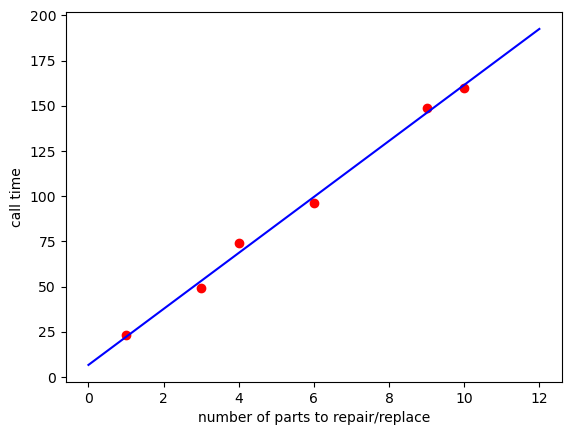

In [5]:
x1 = np.linspace(0,12,100)
#plot result
plt.scatter(x,y,marker="o",color = "red")
plt.plot(x1,Beta_0+Beta_1*x1, color = "blue")
plt.xlabel('number of parts to repair/replace')
plt.ylabel('call time')
plt.show()

While calculating the coefficients $\beta_0$ and $\beta_1$ by hand works, this can be very tedious for large data sets.  Let's recalculate the line of best fit, but using the built in function linregress from the stats package.

In [6]:
from sklearn import linear_model

In [7]:
##can also use linear_model
#x is a single dimension array, it does not have a column specified, so we need to add this by using .reshape(-1,1)
# the -1 means that the entries become the rows and the 1 means that we create 1 column
xr = np.array(x).reshape(-1, 1) 
yr = np.array(y).reshape(-1,1)
reg_ols = linear_model.LinearRegression().fit(xr,yr) 

print(f" b0: {reg_ols.intercept_} b1: {reg_ols.coef_}")


 b0: [6.6504065] b1: [[15.48780488]]


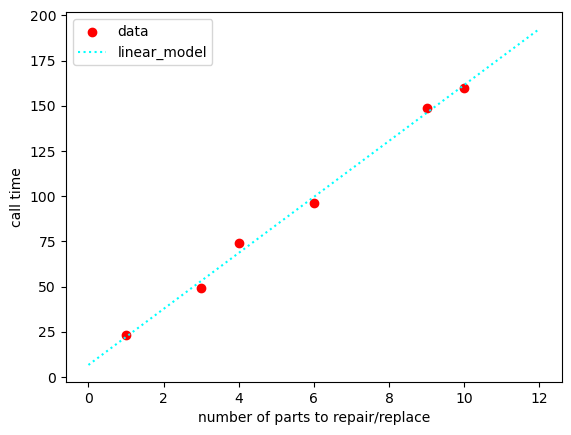

In [8]:
x1r = np.array(x1).reshape(-1,1)
yp = reg_ols.predict(x1r)

plt.scatter(x,y,marker="o",color = "red",label="data")
plt.plot(x1,yp, color = "cyan",linestyle = "dotted",label="linear_model")
plt.xlabel('number of parts to repair/replace')
plt.ylabel('call time')
plt.legend()
plt.show()

In [9]:
#run linregress on data
beta_1, beta_0, r, p, std_err = stats.linregress(x, y)
#print out beta values
print(f"Intercept: {beta_0} and slope: {beta_1}")

Intercept: 6.650406504065032 and slope: 15.487804878048781


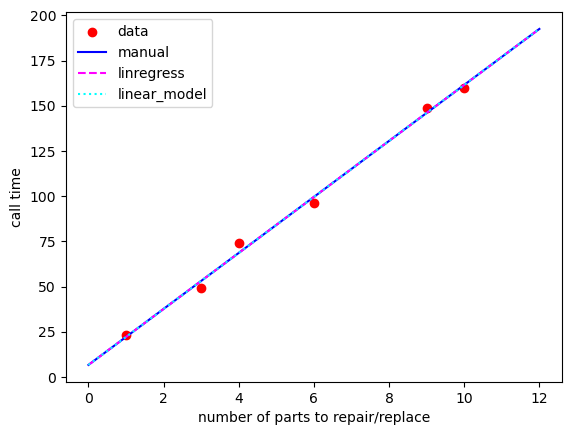

In [10]:
#plot result
plt.scatter(x,y,marker="o",color = "red",label="data")
plt.plot(x1,Beta_0+Beta_1*x1, color = "blue",label="manual")
plt.plot(x1,beta_0+beta_1*x1, color = "magenta",linestyle = "dashed",label="linregress")
plt.plot(x1,yp, color = "cyan",linestyle = "dotted",label="linear_model")
plt.xlabel('number of parts to repair/replace')
plt.ylabel('call time')
plt.legend()
plt.show()

In [11]:
import statsmodels.api as sm

In [12]:
# We need to tell statsmodels to include a constant beta_0 in the regression calculation
x = sm.add_constant(x)
 
#run regression    
reg_1 = sm.OLS(y, x).fit()
 
summary_table = reg_1.summary()
print(summary_table)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     834.6
Date:                Tue, 07 Nov 2023   Prob (F-statistic):           8.54e-06
Time:                        23:08:47   Log-Likelihood:                -15.914
No. Observations:                   6   AIC:                             35.83
Df Residuals:                       4   BIC:                             35.41
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6504      3.412      1.949      0.1

/opt/conda/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Here, we say that the line of best fit is $\hat{y} = 6.64 +15.49x$.

- $\hat{\beta}_0$ is the predicted value of $y$ when $x=0$.  This may not always be useful, as there are some cases where $x$ may never be zero.
- $\hat{\beta}_1$ estimates the average change in $y$ for a unit change in $x$ (i.e., slope).

In the context of our example:
- $\hat{\beta}_0 = 6.64$: service call of $6.64$ minutes  where no components are reparied or replaced (unlikely)
- $\hat{\beta}_1 = 15.49$: on average, the service call time increases by $15.49$ minutes for every additional electrical part that needs to be repaired or replaced.

## Multiple Linear Regression

### MLB Data

Now we will look at some MLB data, which has a random sample of 45 MLB players tracking:
- batavg: batting average (Response variable)
- runs: runs scored per times at bat
- dbls: doubles per times at bat
- strikeouts: strikeouts per times at bat

We will try to predict the batave given runs, dbls, and strikeouts.

1. First calculate the $\beta_i$ coefficients using the matrix formulas from the pre-reading.
2. Compare your results using the `linear_model.LinearRegression().fit(X,Y)` function `sklearn`.

In [13]:
#import data 
mlb_data = pd.read_csv('baseball.csv')

mlb = pd.DataFrame(mlb_data)
mlb.head()

,batavg,runs,dbls,trpls,homeruns,strikeouts
0,0.283,0.144,0.049,0.012,0.013,0.086
1,0.276,0.125,0.039,0.013,0.002,0.062
2,0.281,0.141,0.045,0.021,0.013,0.074
3,0.328,0.189,0.043,0.001,0.030,0.032
4,0.290,0.161,0.044,0.011,0.070,0.076


**Calculating the coefficients by hand using the formula:**

Let's first calculate the $\hat{\vec{\beta}}$ values using the formula $\hat{\vec{\beta}} = (\vec{x}^{\prime}\vec{x})^{-1} \vec{x}^{\prime}\vec{y}$.  

Here, we will use "runs", "dbls", and "strikeouts" as $\vec{x}_1, \vec{x_2},$ and $\vec{x}_3$ inputs and output "batavg" as $\vec{y}$.

In [14]:
#need to add a column of ones so that we can have a intercept in the linear regression
mlb["int"]=1
mlb.head()

,batavg,runs,dbls,trpls,homeruns,strikeouts,int
0,0.283,0.144,0.049,0.012,0.013,0.086,1
1,0.276,0.125,0.039,0.013,0.002,0.062,1
2,0.281,0.141,0.045,0.021,0.013,0.074,1
3,0.328,0.189,0.043,0.001,0.030,0.032,1
4,0.290,0.161,0.044,0.011,0.070,0.076,1


In [15]:
#define X and Y from the data
X = mlb[['int','runs','dbls','strikeouts']]
Y = mlb['batavg']

#make transpose of X
X_transp = X.transpose()

#inverse (x'x)^(-1)
X_mat_inv = np.linalg.inv(np.matmul(np.array(X_transp),np.array(X)))

#calculate beta's: x'y
beta_l = np.matmul(np.array(X_transp),np.array(Y))

#calculate (x'x)^(-1) x'y
beta = np.matmul(X_mat_inv,beta_l)

print('intercept', beta[0])
print('beta_runs', beta[1])
print('beta_dbls', beta[2])
print('beta_strikeouts', beta[3])

intercept 0.16941484911704396
beta_runs 0.5749424682805602
beta_dbls 1.1190822340299098
beta_strikeouts -0.26430950161414124


Nice! We have calculated the coefficients for the multiple linear regression.  Our output suggests that 

batave = 0.16941 + 0.57494 * runs + 1.11908 * dbls - 0.2643 * strikeouts.

This is a bit tedious to code everytime, especially if we would like other information about the regression (e.g., how good the fit is, the variation of the coefficients) and python has some nice built in packages, which not only give us the regression coefficients, but other information that we can use to analyze our model!

In [16]:
#One option is to use linear_model from the scikit learn package
#define X and Y from the data
X = mlb[['runs','dbls','strikeouts']]
Y = mlb['batavg']

reg = linear_model.LinearRegression().fit(X,Y)

r = reg.score(X,Y)
print('b0:', reg.intercept_)
print('b1,b2,b3:', reg.coef_)
print('R square:',r) ## note here that this is R^2 not R^2_{adj}!

b0: 0.16941484911704538
b1,b2,b3: [ 0.57494247  1.11908223 -0.2643095 ]
R square: 0.850037003781138


In [17]:
## convert R^2 to R^2_adj
n = len(Y) #number of observations
k = X.shape[1] #number of predictor inputs (i.e., number of input variables)

R2_adj = 1 - ((1-r)*(n-1)/(n-k-1))
print('R square adjusted:', R2_adj)

R square adjusted: 0.8390641016187823


This tells us that: batave = 0.16941 + 0.57494 * runs + 1.11908 * dbls - 0.2643 * strikeouts... Notice how this is the same fitted regression that we calculated from the matrices!

### Using `statsmodels.api`
We can also use statsmodels.api to run a multiple linear regression.  This package will output a summary table, like many other software programs (e.g., R, SAS).  For linear regression, we will call `sm.OLS(Y, X).fit()` to fit a linear regression where $X$ is the inputs and $Y$ is the output.

Try running `sm.OLS(Y, X).fit()` on the previous MLB example and compare your results with the results from `linear_model.LinearRegression().fit(X,Y)`. 

In [18]:
import statsmodels.api as sm

In [19]:
# We need to tell statsmodels to include a constant beta_0 in the regression calculation
X = sm.add_constant(X)
 
#run regression    
reg_1 = sm.OLS(Y, X).fit()
 
summary_table = reg_1.summary()
print(summary_table)

                            OLS Regression Results                            
Dep. Variable:                 batavg   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     77.47
Date:                Tue, 07 Nov 2023   Prob (F-statistic):           6.17e-17
Time:                        23:08:48   Log-Likelihood:                 119.90
No. Observations:                  45   AIC:                            -231.8
Df Residuals:                      41   BIC:                            -224.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1694      0.015     11.188      0.0

### MLB Data 2

Rerun the mlb data, but include the inputs for trpls and homeruns.  How does the regression change?

In [20]:
X1 = mlb[['runs','dbls','strikeouts','trpls','homeruns']]
Y1 = mlb['batavg']


# We need to tell statsmodels to include a constant beta_0
X1 = sm.add_constant(X1)
 
#run regression    
reg_2 = sm.OLS(Y1, X1).fit()
 
summary_table_1 = reg_2.summary()
print(summary_table_1)

                            OLS Regression Results                            
Dep. Variable:                 batavg   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     47.96
Date:                Tue, 07 Nov 2023   Prob (F-statistic):           1.26e-15
Time:                        23:08:49   Log-Likelihood:                 121.47
No. Observations:                  45   AIC:                            -230.9
Df Residuals:                      39   BIC:                            -220.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1832      0.017     10.685      0.0

We see a very small improvement in $R^2_{adj}$ with inclusion of trpls and homeruns. We also see some slight changes in the value of the coefficients on the constant, runs, dbls, and strikeouts terms.  This is to be expected, since we are running a new optimization for the $\beta$ coefficients with more input variables.  

While we do have more information included in this model, we do not see much improvement in the fit to the data.  